<a href="https://colab.research.google.com/github/JaySharma424/Deep-Learning/blob/main/Diabetic%20Retinopathy/dr_multiclass_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
# from tensorflow.keras.layers.experimental import preprocessing
from tensorflow import keras
from tensorflow.keras import layers,Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Attention
# from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, accuracy_score
import matplotlib.pyplot as plt

In [ ]:
from tensorflow.keras.applications.efficientnet_v2 import EfficientNetV2S, preprocess_input
from google.colab.patches import cv2_imshow
import pandas as pd
import numpy as np
import seaborn as sns
# import imutils
import time
import cv2
# from cuml import SVC
# from sklearn.svm import SVC

In [ ]:
from google.colab import drive


drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_path = "/content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/train_images/train_images/"
valid_path = "/content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/val_images/val_images/"
test_path = "/content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/test_images/test_images/"

In [ ]:
train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/train_1.csv', encoding='utf-8')
test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/test.csv', encoding='utf-8')
valid = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/valid.csv', encoding='utf-8')

In [ ]:
num_classes = 5
epochs = 20

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

In [ ]:
datagen = ImageDataGenerator(
    # Removed preprocessing_function here to allow custom preprocessing later
)

# Ensure the 'id_code' column has the .png extension for dataframe flow
# First, remove any existing '.png' suffixes, then add a single '.png'
train['id_code'] = train['id_code'].apply(lambda x: x.rstrip('.png') + '.png')
valid['id_code'] = valid['id_code'].apply(lambda x: x.rstrip('.png') + '.png')
test['id_code'] = test['id_code'].apply(lambda x: x.rstrip('.png') + '.png')

# Convert 'diagnosis' column to string type for categorical class_mode
train['diagnosis'] = train['diagnosis'].astype(str)
valid['diagnosis'] = valid['diagnosis'].astype(str)
test['diagnosis'] = test['diagnosis'].astype(str)


train_ds = datagen.flow_from_dataframe(
    dataframe=train,
    directory=train_path,
    x_col='id_code',
    y_col='diagnosis',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

validation_ds = datagen.flow_from_dataframe(
    dataframe=valid,
    directory=valid_path,
    x_col='id_code',
    y_col='diagnosis',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_ds = datagen.flow_from_dataframe(
    dataframe=test,
    directory=test_path,
    x_col='id_code',
    y_col='diagnosis',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 2930 validated image filenames belonging to 5 classes.
Found 366 validated image filenames belonging to 5 classes.
Found 366 validated image filenames belonging to 5 classes.


Original sample image shape: (224, 224, 3), dtype: float32
CLAHE processed image shape: (224, 224, 3), dtype: uint8
Augmented image shape: (224, 224, 3), dtype: uint8


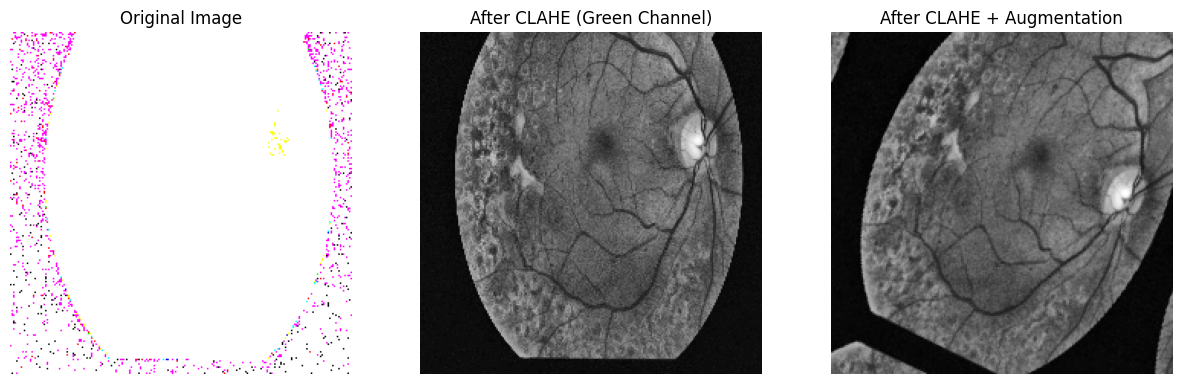

In [ ]:
# Define CLAHE preprocessing function to use green channel
def apply_clahe(image):
    # Convert to unsigned 8-bit integer if not already
    if image.dtype != np.uint8:
        # Assuming input float image is in range [0, 255]
        image = image.astype(np.uint8)

    # Assuming image is in RGB format (R=0, G=1, B=2), extract the green channel
    green_channel = image[:, :, 1]

    # Apply CLAHE to the green channel
    clahe = cv2.createCLAHE(clipLimit=5.0, tileGridSize=(8, 8))
    cl_green = clahe.apply(green_channel)

    # To feed to a 3-channel model, stack the CLAHE processed green channel three times
    final_image = np.stack([cl_green, cl_green, cl_green], axis=-1)

    return final_image


# Helper function to get a single image and label for visualization
def get_single_image_sample(dataset, idx):
    for images, labels in dataset:
        if images.shape[0] > idx:
            # Take the image at the specified index and its corresponding label from the batch
            return images[idx], labels[idx]
    return None, None

# --- User adjustable index --- #
image_index_to_display = 20 # Change this value to view a different image from the batch (0 to BATCH_SIZE-1)
# ----------------------------- #

# Get a sample image from the training dataset
sample_image, sample_label = get_single_image_sample(train_ds, image_index_to_display)

if sample_image is not None:
    print(f"Original sample image shape: {sample_image.shape}, dtype: {sample_image.dtype}")

    # Apply CLAHE
    clahe_image = apply_clahe(sample_image)
    print(f"CLAHE processed image shape: {clahe_image.shape}, dtype: {clahe_image.dtype}")

    # Apply augmentation (requires tensor input, then convert back to numpy)
    # The img_augmentation model expects batches, so we'll add a batch dimension
    augmented_image_tensor = img_augmentation(tf.expand_dims(tf.convert_to_tensor(clahe_image, dtype=tf.float32), 0))
    augmented_image_numpy = augmented_image_tensor[0].numpy().astype(np.uint8)
    print(f"Augmented image shape: {augmented_image_numpy.shape}, dtype: {augmented_image_numpy.dtype}")

    # Display images
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(sample_image)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(clahe_image)
    plt.title('After CLAHE (Green Channel)')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(augmented_image_numpy)
    plt.title('After CLAHE + Augmentation')
    plt.axis('off')

    plt.show()
else:
    print(f"Could not retrieve a sample image at index {image_index_to_display}. Make sure the index is within the batch size.")

In [ ]:
img_augmentation = Sequential(
    [
        tf.keras.layers.RandomRotation(factor=(-0.15, 0.15)),
        tf.keras.layers.RandomFlip(),
        tf.keras.layers.RandomContrast(factor=0.1),
    ],
    name="img_augmentation",
)

In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess_input

# EfficientNetV2S and its preprocess_input are already imported in cell RU-XF9_I1HT-.
# Alias preprocess_input from efficientnet_v2 for clarity and consistent use.
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as efficientnet_preprocess_input

# Load InceptionV3 base model
inception_base = InceptionV3(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
for layer in inception_base.layers:
    layer.trainable = False
inception_feature_extractor = Model(inputs=inception_base.input, outputs=inception_base.output, name='inception_feature_extractor')
print("InceptionV3 base model loaded and layers frozen.")

# Load EfficientNetV2S base model (also frozen)
efficientnet_base = EfficientNetV2S(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
for layer in efficientnet_base.layers:
    layer.trainable = False
efficientnet_feature_extractor = Model(inputs=efficientnet_base.input, outputs=efficientnet_base.output, name='efficientnet_feature_extractor')
print("EfficientNetV2S base model loaded and layers frozen.")

InceptionV3 base model loaded and layers frozen.
EfficientNetV2S base model loaded and layers frozen.


### Feature Extraction Functions

These functions are crucial for applying the defined preprocessing pipeline (CLAHE, augmentation, and model-specific `preprocess_input`) to entire datasets before feature extraction and model training. They ensure that each image undergoes the necessary transformations consistently.

In [ ]:
def feature_extraction_generator(data_generator, img_augmentation_model, inception_preprocess_func, efficientnet_preprocess_func):
    """
    Generator to apply CLAHE, augmentation, and model-specific preprocessing
    to batches of images from an ImageDataGenerator.
    """
    for batch_x, batch_y in data_generator:
        # 1. Apply CLAHE to each image in the batch
        clahe_batch = np.array([apply_clahe(img) for img in batch_x])

        # 2. Apply augmentation
        # Convert to TensorFlow tensor, apply augmentation, then convert back to NumPy
        augmented_batch = img_augmentation_model(tf.convert_to_tensor(clahe_batch, dtype=tf.float32)).numpy()

        # 3. Apply model-specific preprocessing
        # InceptionV3 and EfficientNetV2S require different preprocessing
        inception_preprocessed_batch = inception_preprocess_func(augmented_batch)
        efficientnet_preprocessed_batch = efficientnet_preprocess_func(augmented_batch)

        yield [inception_preprocessed_batch, efficientnet_preprocessed_batch], batch_y

def extract_features_parallel(data_generator_fe, inception_extractor, efficientnet_extractor, steps):
    """
    Extracts features from both InceptionV3 and EfficientNetV2S in parallel
    using a custom feature extraction generator.

    Args:
        data_generator_fe: A generator yielding preprocessed batches of images and labels.
        inception_extractor: The InceptionV3 feature extractor model.
        efficientnet_extractor: The EfficientNetV2S feature extractor model.
        steps (int): The number of batches to yield from the generator.

    Returns:
        Tuple of numpy arrays: (inception_features, efficientnet_features, labels)
    """
    all_inception_features = []
    all_efficientnet_features = []
    all_labels = []

    for i, ([inception_batch, efficientnet_batch], labels_batch) in enumerate(data_generator_fe):
        if i >= steps:
            break

        inception_features = inception_extractor.predict(inception_batch, verbose=0)
        efficientnet_features = efficientnet_extractor.predict(efficientnet_batch, verbose=0)

        all_inception_features.append(inception_features)
        all_efficientnet_features.append(efficientnet_features)
        all_labels.append(labels_batch)

    return (
        np.concatenate(all_inception_features),
        np.concatenate(all_efficientnet_features),
        np.concatenate(all_labels)
    )

In [ ]:
def get_inception_features_from_image_path(img_path):
    # 1. Load image
    img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img) # Output is float32 in range [0, 255]

    # 2. Apply CLAHE
    clahe_image = apply_clahe(img_array)

    # 3. Apply augmentation (expects TF tensor, adds batch dim)
    augmented_image_tensor = img_augmentation(tf.expand_dims(tf.convert_to_tensor(clahe_image, dtype=tf.float32), 0))
    augmented_image_np = augmented_image_tensor.numpy()

    # 4. Apply InceptionV3-specific preprocessing
    inception_input = inception_preprocess_input(augmented_image_np)

    # 5. Extract features using InceptionV3 model
    features = inception_feature_extractor.predict(inception_input, verbose=0)
    return features

In [ ]:
# Define input layers for each feature set
inception_input = layers.Input(shape=inception_feature_extractor.output_shape[1:], name='inception_features_input')
efficientnet_input = layers.Input(shape=efficientnet_feature_extractor.output_shape[1:], name='efficientnet_features_input')

# Flatten the outputs of feature extractors before concatenation
inception_flat = layers.Flatten()(inception_input)
efficientnet_flat = layers.Flatten()(efficientnet_input)

# Concatenate the flattened features
concatenated_features = layers.concatenate([inception_flat, efficientnet_flat], axis=-1)

# Add a classification head
x = layers.Dense(512, activation='relu')(concatenated_features)
x = layers.Dropout(0.25)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.25)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.25)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.25)(x)
output_layer = layers.Dense(num_classes, activation='softmax', name='classification_output')(x)

# Create the combined model
combined_model = Model(inputs=[inception_input, efficientnet_input], outputs=output_layer)

# Compile the model
combined_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

combined_model.summary()

print("Combined feature classification model built and compiled.")

# Define Early Stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Define ReduceLROnPlateau callback
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=0.00001
)

print("EarlyStopping and ReduceLROnPlateau callbacks defined.")

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ inception_features… │ (None, 5, 5,      │          0 │ -                 │
│ (InputLayer)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnet_featu… │ (None, 7, 7,      │          0 │ -                 │
│ (InputLayer)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_10          │ (None, 51200)     │          0 │ inception_featur… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_11          │ (None, 62720)     │          0 │ efficientnet_fea… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_12      │ (None, 113920)    │          0 │ flatten_10[0][0], │
│ (Concatenate)       │                   │            │ flatten_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 512)       │ 58,327,552 │ concatenate_12[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 512)       │          0 │ dense_22[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 256)       │    131,328 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 256)       │          0 │ dense_23[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 128)       │     32,896 │ dropout_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 128)       │          0 │ dense_24[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 64)        │      8,256 │ dropout_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 64)        │          0 │ dense_25[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification_out… │ (None, 5)         │        325 │ dropout_15[0][0]  │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 58,500,357 (223.16 MB)

 Trainable params: 58,500,357 (223.16 MB)

 Non-trainable params: 0 (0.00 B)

Combined feature classification model built and compiled.
EarlyStopping and ReduceLROnPlateau callbacks defined.


In [ ]:
import matplotlib.cm as cm

def make_gradcam_heatmap(img_array_preprocessed_for_base_model, base_model, last_conv_layer_name, num_classes, pred_index=None):
    """
    Generates a Grade-CAM heatmap for a given image and base model.

    Args:
        img_array_preprocessed_for_base_model (np.array): Preprocessed image array ready for the base model (with batch dimension).
        base_model (tf.keras.Model): The pre-trained base model (e.g., InceptionV3 without top).
        last_conv_layer_name (str): The name of the last convolutional layer in the base model.
        num_classes (int): Number of output classes for the classification head.
        pred_index (int, optional): Index of the class for which to generate the heatmap.
                                    If None, the top predicted class is used. Defaults to None.

    Returns:
        np.array: The computed heatmap, normalized to [0, 1].
    """

    # 1. Create a model that returns the activation of the last conv layer
    #    and the output of the base model (features)
    #    when fed with its original input tensor.
    #    This effectively "splits" the original base_model.
    grad_model_core = keras.Model(
        inputs=base_model.inputs,
        outputs=[base_model.get_layer(last_conv_layer_name).output, base_model.output]
    )

    # 2. Define the classification head that will sit on top of the base model's features.
    classifier_input = keras.Input(shape=base_model.output_shape[1:]) # Input to the classifier head
    x = layers.GlobalAveragePooling2D()(classifier_input)
    classifier_output = layers.Dense(num_classes, activation="softmax")(x)
    classifier = keras.Model(classifier_input, classifier_output)

    # 3. Create the final Grad-CAM model that takes an image input,
    #    feeds it through grad_model_core, and then feeds the features
    #    through the classifier.
    inputs_for_gradcam = keras.Input(shape=base_model.input_shape[1:])

    # Get last conv layer output and base model features from the grad_model_core
    last_conv_layer_output_from_gradcam_inputs, base_features_from_gradcam_inputs = grad_model_core(inputs_for_gradcam)

    # Get predictions from the classifier head
    preds_from_gradcam_inputs = classifier(base_features_from_gradcam_inputs)

    # This is the full model we'll use with tf.GradientTape
    grad_model_full = keras.Model(
        inputs=inputs_for_gradcam,
        outputs=[last_conv_layer_output_from_gradcam_inputs, preds_from_gradcam_inputs]
    )

    # Compute gradients of the top predicted class with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        # Watch the input image tensor for gradients
        img_array_preprocessed_tensor = tf.convert_to_tensor(img_array_preprocessed_for_base_model, dtype=tf.float32)

        last_conv_layer_output, preds = grad_model_full(img_array_preprocessed_tensor)

        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # This is the gradient of the output neuron (top predicted or chosen)
    # with regard to the output feature map of the last convolutional layer.
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient
    # over a specific feature map channel.
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # We multiply each channel in the feature map array by "how important that channel is"
    # to the top predicted class.
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, normalize the heatmap to be between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_orig, heatmap, alpha=0.4, title='Grade-CAM'):
    """
    Displays the Grade-CAM heatmap superimposed on the original image.

    Args:
        img_orig (np.array): The original image (unprocessed, 0-255).
        heatmap (np.array): The computed heatmap (normalized to [0, 1]).
        alpha (float, optional): Transparency factor for the heatmap. Defaults to 0.4.
        title (str, optional): Title for the displayed image. Defaults to 'Grade-CAM'.
    """
    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    jet = cm.get_cmap("jet")

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img_orig.shape[1], img_orig.shape[0]))
    jet_heatmap = keras.utils.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * alpha + img_orig
    superimposed_img = keras.utils.array_to_img(superimposed_img)

    # Display Image
    plt.figure(figsize=(8, 8))
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.title(title)
    plt.show()

### Grade-CAM Demonstration

Let's demonstrate Grade-CAM using a sample image from the training set and the InceptionV3 base model. This will show which regions of the image the InceptionV3 model focused on for its prediction.

/tmp/ipykernel_5004/2307158761.py:94: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


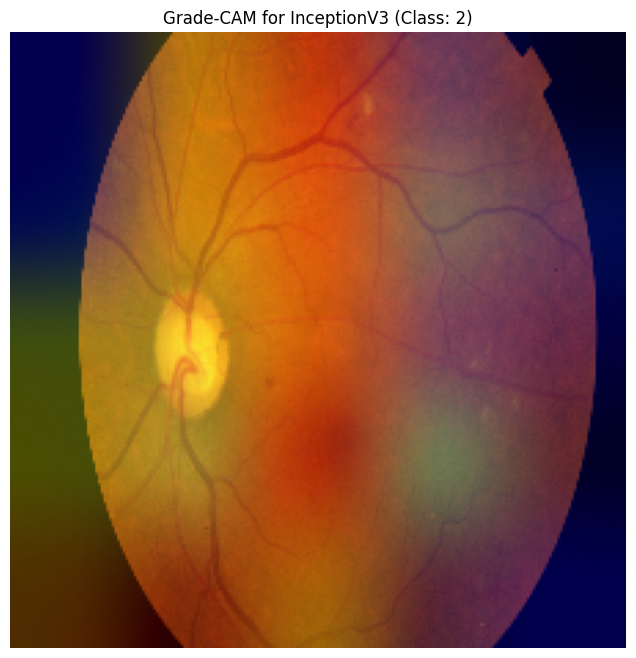

In [ ]:
# 1. Get a sample image (original image, not processed yet)
# We will use the same image_index_to_display as defined earlier

# Retrieve a single sample (image and label) from the train_ds for demonstration
# The get_single_image_sample function returns a float32 image in [0, 255] range.
orig_sample_image_float, sample_label = get_single_image_sample(train_ds, image_index_to_display)

if orig_sample_image_float is not None:
    # Convert original image to uint8 for display, if it's not already
    original_image_display = orig_sample_image_float.astype(np.uint8)

    # 2. Apply CLAHE
    clahe_image = apply_clahe(orig_sample_image_float)

    # 3. Apply augmentation (expects TF tensor, adds batch dim)
    augmented_image_tensor = img_augmentation(tf.expand_dims(tf.convert_to_tensor(clahe_image, dtype=tf.float32), 0))
    augmented_image_np = augmented_image_tensor.numpy()

    # 4. Apply InceptionV3-specific preprocessing (for the base model)
    img_for_inception = inception_preprocess_input(augmented_image_np)

    # 5. Determine the last convolutional layer name for InceptionV3
    last_conv_layer_name_inception = inception_base.layers[-1].name # Typically 'mixed10' for InceptionV3

    # 6. Generate the Grad-CAM heatmap
    heatmap_inception = make_gradcam_heatmap(
        img_for_inception,
        inception_base,
        last_conv_layer_name_inception,
        num_classes
    )

    # 7. Display the original image and the Grad-CAM heatmap
    display_gradcam(original_image_display, heatmap_inception, title=f'Grade-CAM for InceptionV3 (Class: {tf.argmax(sample_label).numpy()})')
else:
    print(f"Could not retrieve sample image for Grade-CAM at index {image_index_to_display}.")

In [ ]:
def preprocess_image(img_path):
  img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
  img_array = img_to_array(img)
  img_array = np.expand_dims(img_array, axis=0)
  # Using efficientnet_preprocess_input as a default for single image preprocessing.
  # If you intend to use this for InceptionV3, replace it with inception_preprocess_input.
  return efficientnet_preprocess_input(img_array)

In [ ]:
# 1. Feature Extraction
print("Starting parallel feature extraction for all datasets...")

# Calculate steps per epoch for each generator
train_steps = train_ds.samples // BATCH_SIZE
validation_steps = validation_ds.samples // BATCH_SIZE
test_steps = test_ds.samples // BATCH_SIZE

# Create the custom data generators for feature extraction
train_fe_generator = feature_extraction_generator(train_ds, img_augmentation, inception_preprocess_input, efficientnet_preprocess_input)
validation_fe_generator = feature_extraction_generator(validation_ds, img_augmentation, inception_preprocess_input, efficientnet_preprocess_input)
test_fe_generator = feature_extraction_generator(test_ds, img_augmentation, inception_preprocess_input, efficientnet_preprocess_input)

# Extract features for each dataset
train_inception_features, train_efficientnet_features, train_labels = extract_features_parallel(train_fe_generator, inception_feature_extractor, efficientnet_feature_extractor, train_steps)
print(f"Train Inception Features shape: {train_inception_features.shape}, EfficientNet Features shape: {train_efficientnet_features.shape}, Labels shape: {train_labels.shape}")

validation_inception_features, validation_efficientnet_features, validation_labels = extract_features_parallel(validation_fe_generator, inception_feature_extractor, efficientnet_feature_extractor, validation_steps)
print(f"Validation Inception Features shape: {validation_inception_features.shape}, EfficientNet Features shape: {validation_efficientnet_features.shape}, Labels shape: {validation_labels.shape}")

test_inception_features, test_efficientnet_features, test_labels = extract_features_parallel(test_fe_generator, inception_feature_extractor, efficientnet_feature_extractor, test_steps)
print(f"Test Inception Features shape: {test_inception_features.shape}, EfficientNet Features shape: {test_efficientnet_features.shape}, Labels shape: {test_labels.shape}")

print("Feature extraction completed for all datasets.")

# 2. Train the combined model
print("\nStarting training of the combined model...")

history = combined_model.fit(
    [train_inception_features, train_efficientnet_features],
    train_labels,
    epochs=epochs,
    validation_data=([validation_inception_features, validation_efficientnet_features], validation_labels),
    callbacks=[early_stopping, reduce_lr]
)

print("\nModel training completed.")

Starting parallel feature extraction for all datasets...


Train Inception Features shape: (2898, 5, 5, 2048), EfficientNet Features shape: (2898, 7, 7, 1280), Labels shape: (2898, 5)
Validation Inception Features shape: (352, 5, 5, 2048), EfficientNet Features shape: (352, 7, 7, 1280), Labels shape: (352, 5)
Test Inception Features shape: (352, 5, 5, 2048), EfficientNet Features shape: (352, 7, 7, 1280), Labels shape: (352, 5)
Feature extraction completed for all datasets.

Starting training of the combined model...
Epoch 1/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 14s 70ms/step - accuracy: 0.4331 - loss: 7.6525 - val_accuracy: 0.5994 - val_loss: 1.0803 - learning_rate: 0.0010
Epoch 2/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5676 - loss: 1.2853 - val_accuracy: 0.6875 - val_loss: 0.9268 - learning_rate: 0.0010
Epoch 3/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6508 - loss: 0.9760 - val_accuracy: 0.7131 - val_loss: 0.8104 - learning_rate: 0.0010
Epoch 4/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6815 - loss: 0.97

### Verification of Preprocessing Pipeline

Now that the `feature_extraction_generator` and `extract_features_parallel` functions are defined, we can confirm how the preprocessing steps are applied:

1.  **`train_ds`, `validation_ds`, `test_ds`:** These are your initial `ImageDataGenerator` outputs, providing batches of raw images.
2.  **`feature_extraction_generator`:** This custom generator wraps around your `ImageDataGenerator`.
    *   For each batch, it first calls `apply_clahe` on every image.
    *   Then, it passes the CLAHE-processed batch to `img_augmentation`.
    *   Finally, it applies the respective `inception_preprocess_input` and `efficientnet_preprocess_input` functions to the augmented images, creating two separate streams of preprocessed images ready for each feature extractor.
3.  **`extract_features_parallel`:** This function consumes the batches from `feature_extraction_generator`.
    *   It takes the already preprocessed batches (one for InceptionV3 and one for EfficientNetV2S) and feeds them into their respective frozen base models (`inception_feature_extractor` and `efficientnet_feature_extractor`) to extract features.
    *   The extracted features, along with the labels, are then concatenated to form the final datasets (`train_inception_features`, `train_efficientnet_features`, `train_labels`, etc.).

Therefore, **yes, all your preprocessing steps (CLAHE, augmentation, and both model-specific `preprocess_input` functions) are applied sequentially to the images before feature extraction occurs, and these extracted features are then used to train your `combined_model`**.

Making predictions on the validation set...
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       167
           1       0.00      0.00      0.00        38
           2       0.53      0.89      0.66       101
           3       0.00      0.00      0.00        21
           4       0.00      0.00      0.00        25

    accuracy                           0.72       352
   macro avg       0.29      0.37      0.32       352
weighted avg       0.58      0.72      0.64       352


--- Confusion Matrix ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


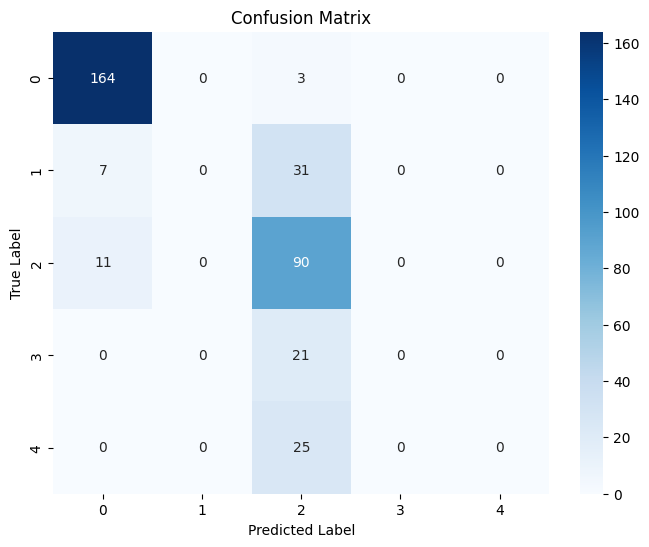


--- Cohen's Kappa Score: 0.5481 ---

--- ROC AUC Curves ---


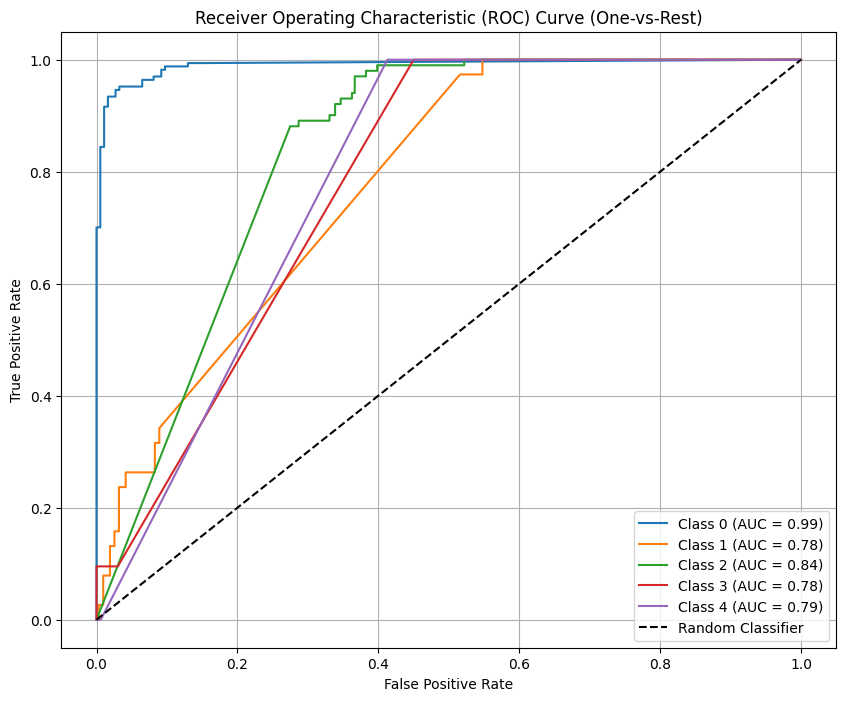


--- Precision-Recall Curves ---


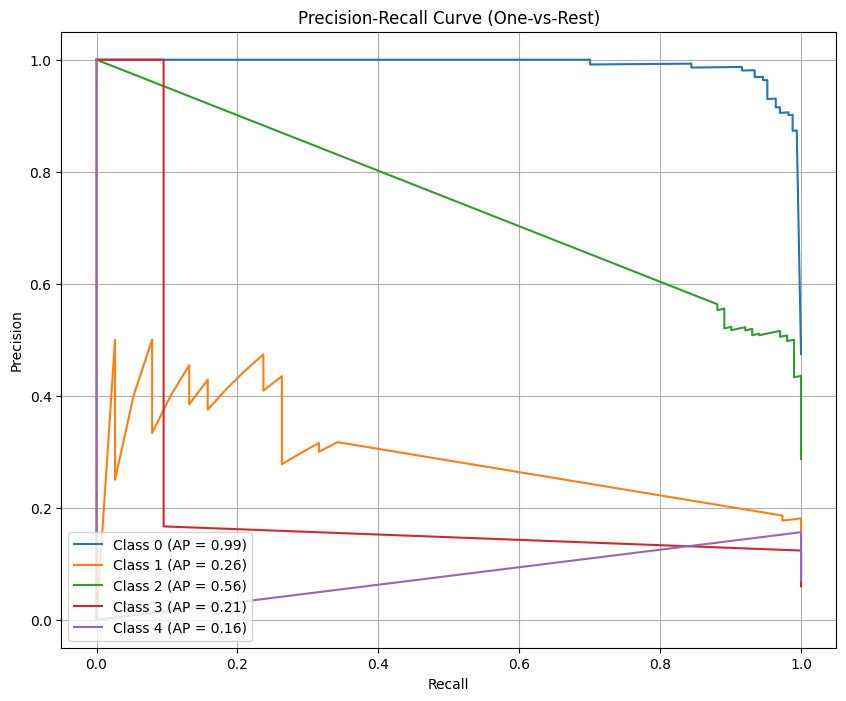

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, roc_curve, auc, precision_recall_curve, average_precision_score
import numpy as np
import seaborn as sns

# 1. Make predictions on the validation set
print("Making predictions on the validation set...")
y_pred_probs = combined_model.predict([validation_inception_features, validation_efficientnet_features])
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(validation_labels, axis=1)

# Get class labels from the generator
class_labels = list(train_ds.class_indices.keys())

print("\n--- Classification Report ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_labels))

# 2. Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 3. Cohen's Kappa Score
kappa = cohen_kappa_score(y_true_classes, y_pred_classes)
print(f"\n--- Cohen's Kappa Score: {kappa:.4f} ---")

# 4. ROC AUC Curve (One-vs-Rest for multi-class)
print("\n--- ROC AUC Curves ---")
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(validation_labels[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {class_labels[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# 5. Precision-Recall Curve (One-vs-Rest for multi-class)
print("\n--- Precision-Recall Curves ---")
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(validation_labels[:, i], y_pred_probs[:, i])
    avg_precision = average_precision_score(validation_labels[:, i], y_pred_probs[:, i])
    plt.plot(recall, precision, label=f'Class {class_labels[i]} (AP = {avg_precision:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (One-vs-Rest)')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()


### Save the Combined Model

To allow for easy loading and further fine-tuning in future sessions or other notebooks, the `combined_model` will be saved to your Google Drive. This will store the model's architecture, weights, and optimizer state.

In [ ]:
model_save_path = '/content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/combined_model.h5'
combined_model.save(model_save_path)
print(f"Combined model saved to: {model_save_path}")

Combined model saved to: /content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/combined_model.h5
